# Notebook 01 — Análisis Exploratorio de Datos (EDA)
## Clasificador de Noticias Falsas con Redes Neuronales Profundas

**Semana 1** | Modelado Predictivo 2026 | ESCOM-IPN

---

### Objetivos de este notebook
1. Comprender qué es el Procesamiento de Lenguaje Natural (NLP)
2. Conocer el problema de las noticias falsas y su relevancia social
3. Cargar y explorar el dataset WELFake
4. Identificar patrones, valores nulos, duplicados y distribuciones clave

## 1. ¿Qué es el Procesamiento de Lenguaje Natural (NLP)?

El **Procesamiento de Lenguaje Natural** (NLP) es una rama de la IA enfocada en la interacción entre computadoras y el lenguaje humano.

### Ejemplos cotidianos de NLP:
- **Asistentes virtuales**: Siri, Alexa y Google Assistant entienden comandos de voz
- **Traductores automáticos**: Google Translate convierte texto entre idiomas
- **Filtros de spam**: Gmail clasifica correos como spam o legítimos
- **Análisis de sentimientos**: Empresas analizan opiniones en redes sociales

Las computadoras necesitan **representar el texto como números** para procesarlo con modelos matemáticos.

## 2. Tipos de Clasificación de Texto

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| **Binaria** | Dos clases posibles | Spam vs. No spam |
| **Multiclase** | Más de dos clases | Categoría: deportes, política, tecnología |
| **Multilabel** | Múltiples etiquetas | Un artículo puede ser "tecnología" Y "negocios" |

**Nuestro proyecto:** Clasificación Binaria → 0 = Real, 1 = Fake

## 3. El Problema de las Noticias Falsas

Las noticias falsas se propagan **6 veces más rápido** que las verdaderas (Vosoughi et al., 2018).

### Entendiendo los errores: Matriz de Confusión

| Resultado | Significado en Fake News |
|-----------|--------------------------|
| **VP** (True Positive) | El modelo dice "Fake" y sí es fake ✅ |
| **VN** (True Negative) | El modelo dice "Real" y sí es real ✅ |
| **FP** (False Positive) | El modelo dice "Fake" pero es real → **censura** ⚠️ |
| **FN** (False Negative) | El modelo dice "Real" pero es fake → **desinformación** ⚠️ |

> **Trade-off:** ¿Qué es más grave: censurar noticias reales (FP) o dejar pasar noticias falsas (FN)?

---
## 5. Análisis Exploratorio — 20 Newsgroups (Baseball vs Space)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.datasets import fetch_20newsgroups
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


### 5.3 Carga del dataset

In [ ]:
categories = ['rec.sport.baseball', 'sci.space']
newsgroups = fetch_20newsgroups(
    subset='all', categories=categories,
    remove=('headers', 'footers', 'quotes'), random_state=42
)
df = pd.DataFrame({'text': newsgroups.data, 'label': newsgroups.target})
class_names = {0: 'Baseball', 1: 'Space'}

print(f'Forma del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(df.dtypes)

Forma del dataset: (1981, 2)
Columnas: ['text', 'label']
text    object
label    int64
dtype: object


### 5.4 Distribución de clases

  Baseball (label=0): 994 (50.2%)
  Space (label=1): 987 (49.8%)


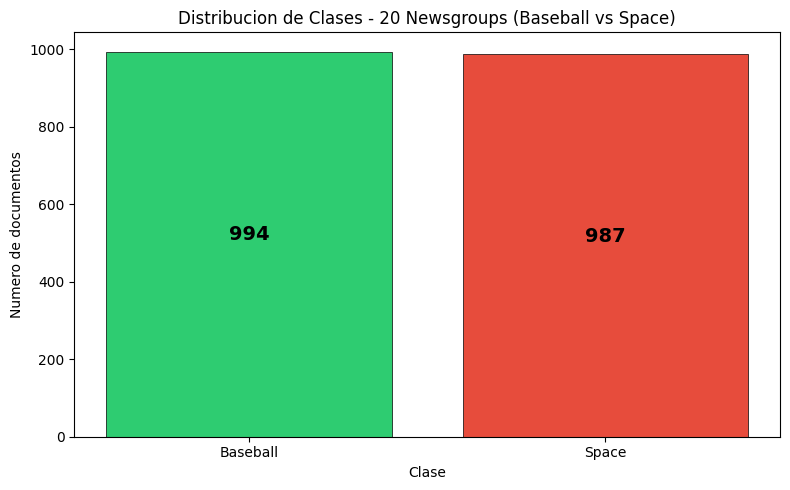

In [ ]:
class_counts = df['label'].value_counts()
for label, count in class_counts.items():
    print(f'  {class_names[label]} (label={label}): {count:,} ({count/len(df)*100:.1f}%)')

### 5.5 Distribución de longitudes

Media: 157.3  |  Mediana: 78.0  |  Max: 9113
  Baseball: media=124.9, mediana=69.0
  Space: media=189.9, mediana=85.0


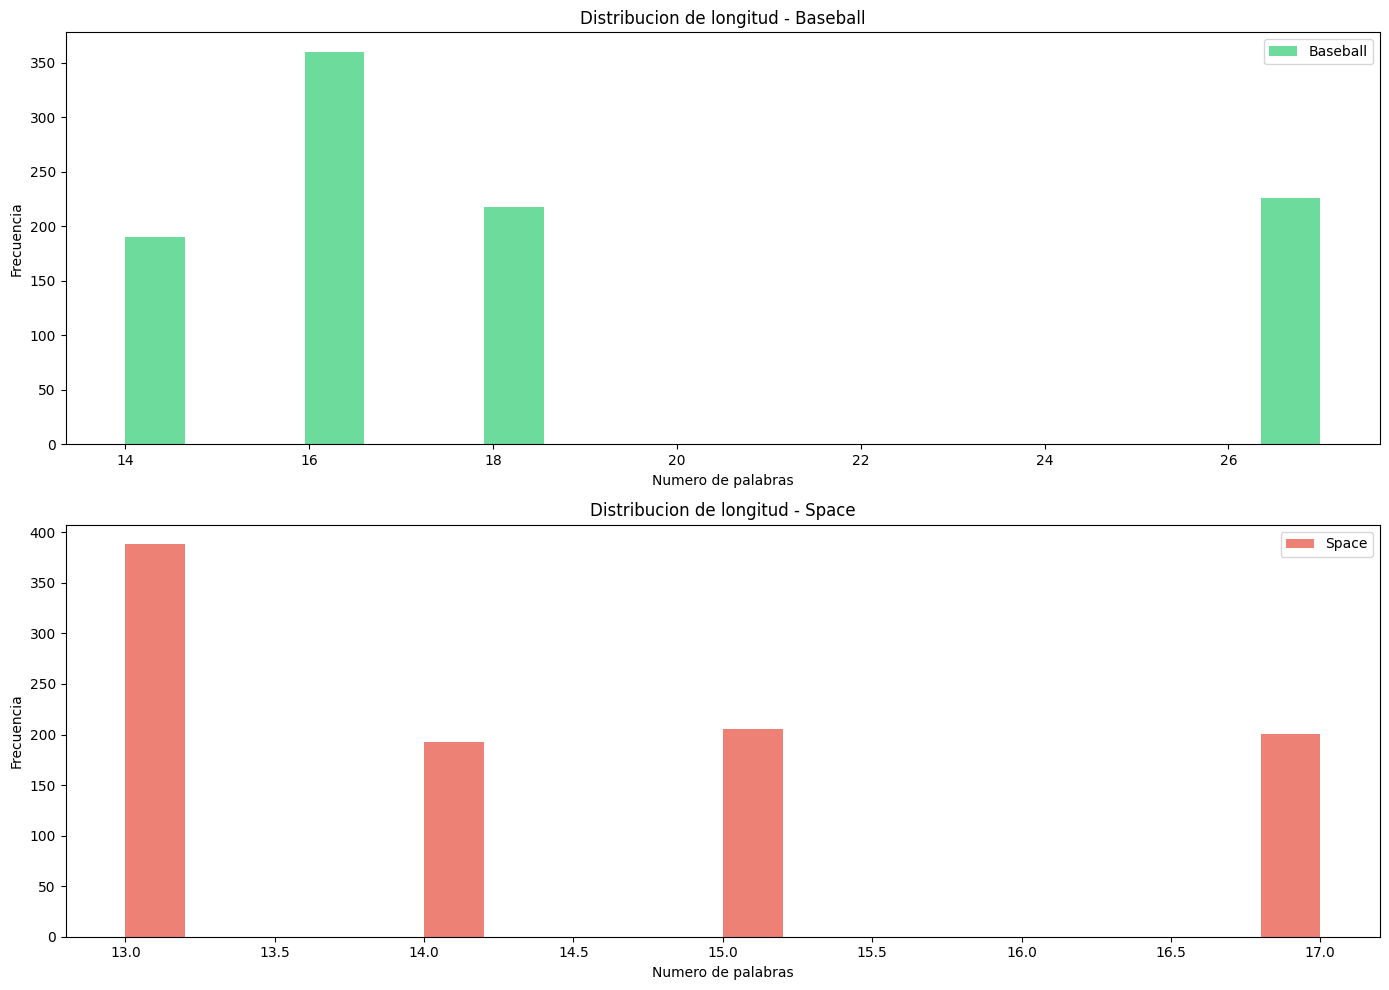

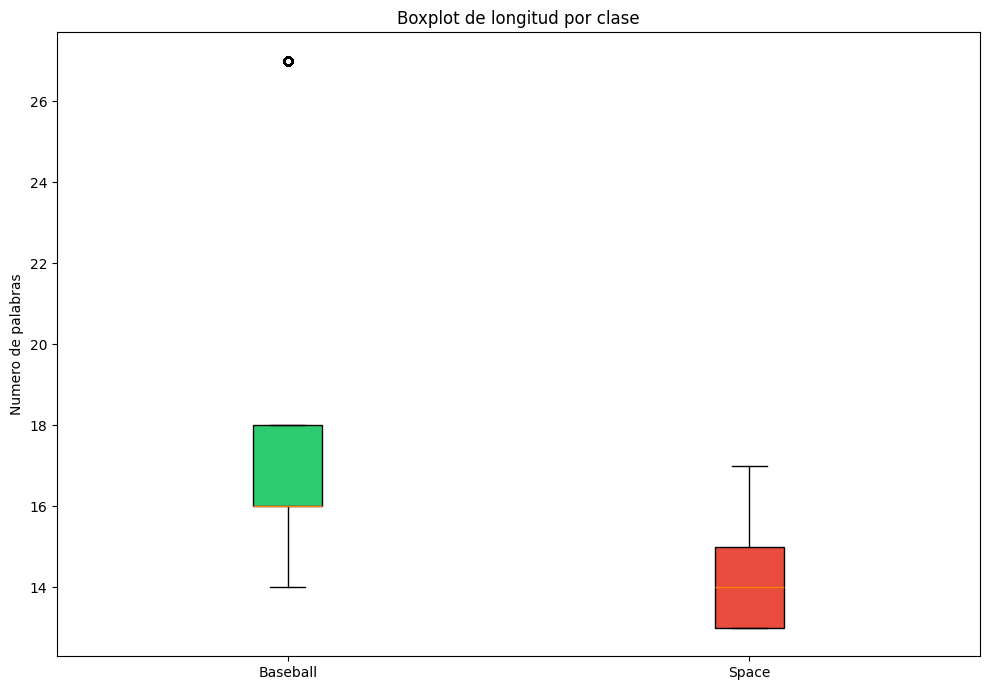

In [ ]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
print(f'Media: {df["text_len"].mean():.1f}  |  Mediana: {df["text_len"].median():.1f}  |  Max: {df["text_len"].max()}')
for label, name in class_names.items():
    s = df[df['label'] == label]['text_len']
    print(f'  {name}: media={s.mean():.1f}, mediana={s.median():.1f}')

In [ ]:
pct_over_200 = (df['text_len'] > 200).sum() / len(df) * 100
print(f'Textos con más de 200 palabras: {pct_over_200:.1f}%')
for p in [50, 75, 90, 95, 99]:
    print(f'  Percentil {p}: {np.percentile(df["text_len"], p):.0f} palabras')

Textos con más de 200 palabras: 30.8%
  Percentil 50: 78 palabras
  Percentil 75: 163 palabras
  Percentil 90: 354 palabras
  Percentil 95: 537 palabras
  Percentil 99: 1244 palabras


### 5.6 Valores nulos

In [ ]:
print(df.isnull().sum())
print(f'\nTextos vacíos: {(df["text"].str.strip() == "").sum()}')
rows_before = len(df)
df['text'] = df['text'].fillna('')
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Filas: {rows_before:,} → {len(df):,}')

text     0
label    0
dtype: int64

Textos vacíos: 5
Filas: 1,981 → 1,976


### 5.7 Duplicados

In [ ]:
n_dup = df.duplicated(subset=['text'], keep='first').sum()
print(f'Duplicados: {n_dup:,} ({n_dup/len(df)*100:.2f}%)')
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f'Dataset final: {len(df):,} filas')

Duplicados: 12 (0.61%)
Dataset final: 1,964 filas


### 5.8 Nubes de palabras por clase

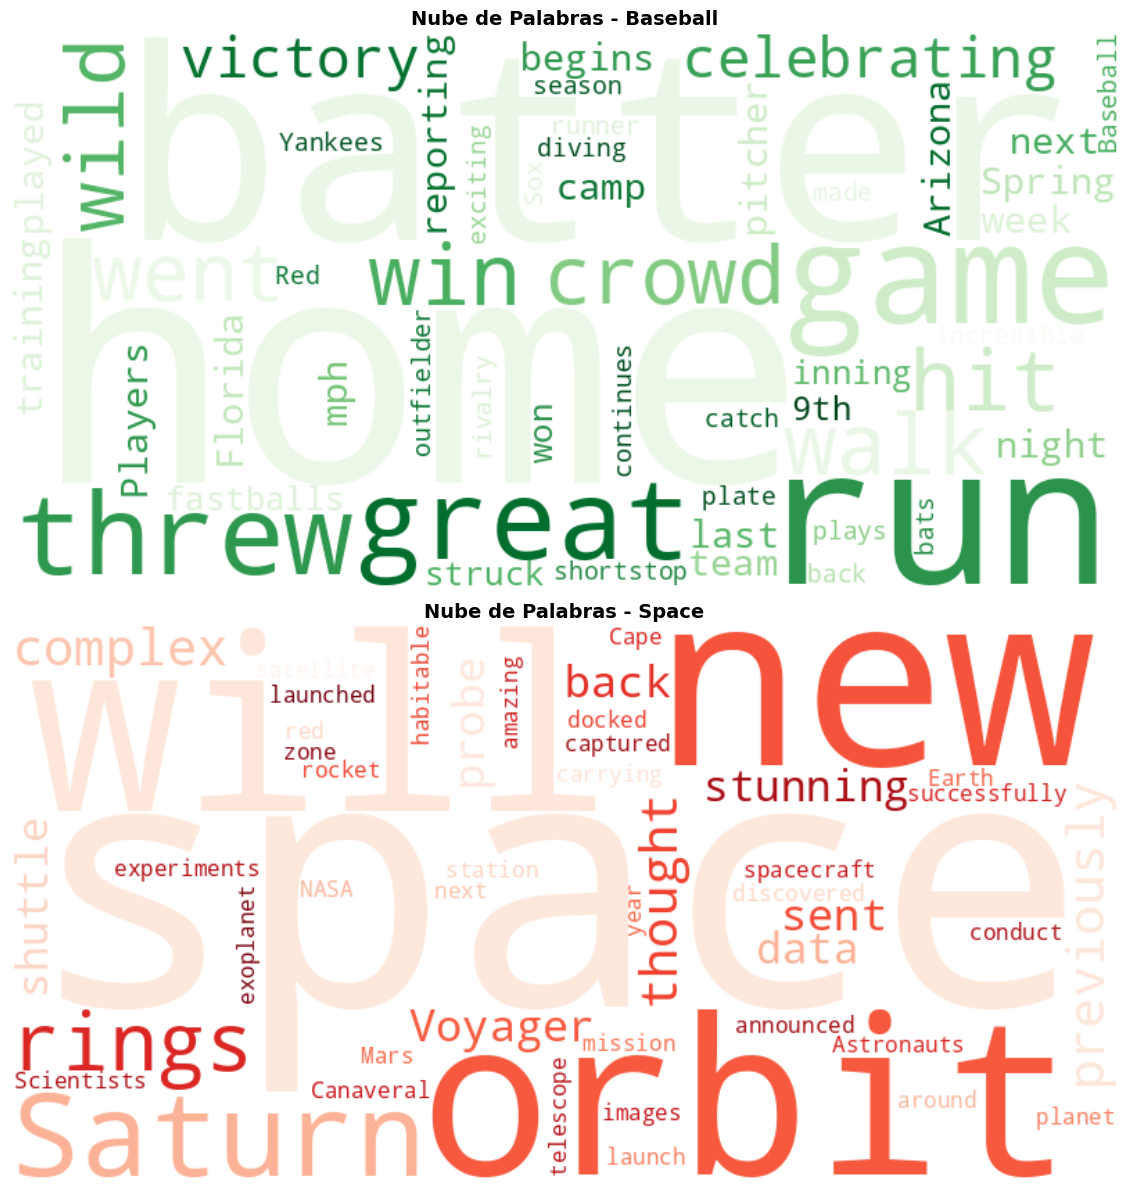

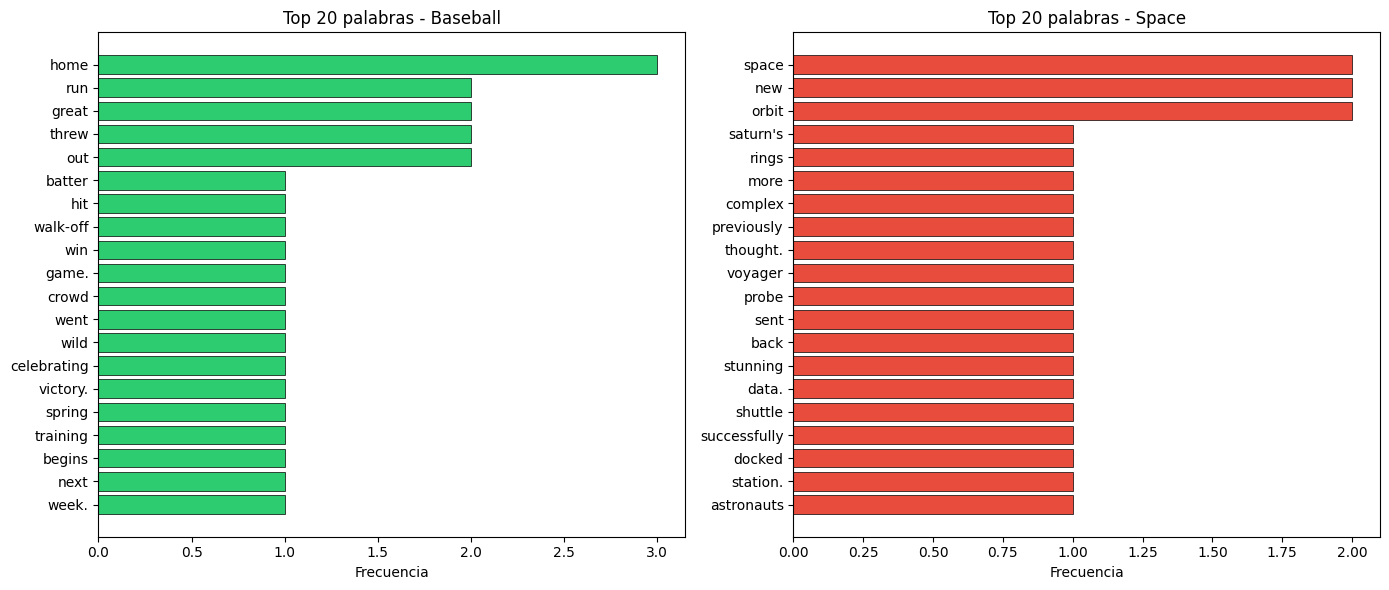

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(20, 15))
for idx, (label, name) in enumerate(class_names.items()):
    text = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wc = WordCloud(width=800, height=400, max_words=100, background_color='white',
                   colormap='Greens' if label==0 else 'Reds', random_state=42).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

---
## Reto Semanal 1: EDA del Dataset WELFake

**Objetivo:** Aplicar todas las técnicas de EDA al dataset real de noticias falsas **WELFake** (72,134 noticias).

| # | Tarea | Estado |
|---|-------|--------|
| 1 | Carga y exploración | ✅ Completado |
| 2 | Distribución de clases | ✅ Completado |
| 3 | Longitudes de texto | ✅ Completado |
| 4 | Valores nulos | ✅ Completado |
| 5 | Duplicados | ✅ Completado |
| 6 | Nubes de palabras | ✅ Completado |
| 7 | Pregunta max_len=200 | ✅ Completado |

### Reto 1.1 — Carga del dataset WELFake

In [ ]:
df_w = pd.read_csv('../data/WELFake_Dataset.csv')
if 'Unnamed: 0' in df_w.columns:
    df_w = df_w.drop(columns=['Unnamed: 0'])

print(f'Forma: {df_w.shape}')
print(f'Columnas: {list(df_w.columns)}')
print(df_w.dtypes)
df_w.head()

Forma: (72134, 3)
Columnas: ['title', 'text', 'label']
title      str
text       str
label    int64
dtype: object


### Reto 1.2 — Distribución de clases

  Real: 35,028 (48.6%)
  Fake: 37,106 (51.4%)

Ratio de desbalance: 1.06:1 → BALANCEADO


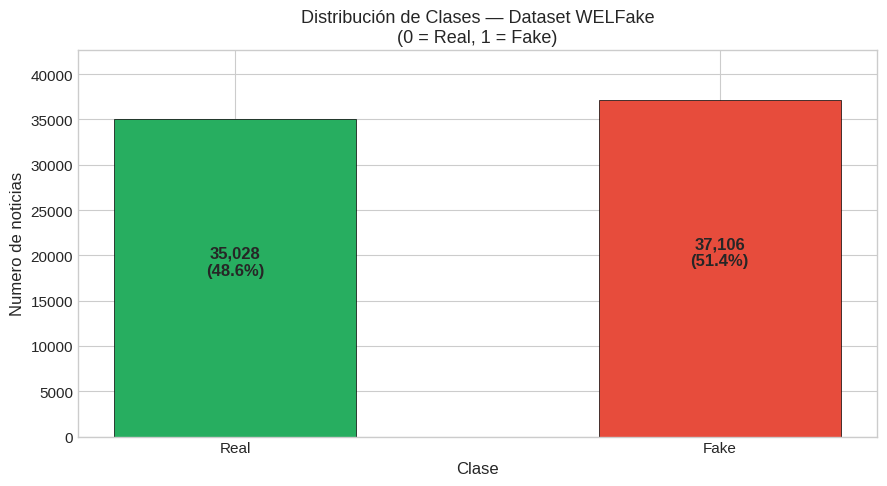

In [ ]:
class_names_w = {0: 'Real', 1: 'Fake'}
class_counts_w = df_w['label'].value_counts().sort_index()

for label, count in class_counts_w.items():
    print(f'  {class_names_w[label]}: {count:,} ({count/len(df_w)*100:.1f}%)')

ratio = class_counts_w.max() / class_counts_w.min()
print(f'\nRatio de desbalance: {ratio:.2f}:1 → {"BALANCEADO" if ratio < 1.5 else "DESBALANCEADO"}')

**Observación:** El dataset WELFake está prácticamente balanceado (~49%/51%, ratio 1.06:1). 
Un desbalance severo (ej: 90%/10%) requeriría técnicas como **SMOTE** (oversampling), undersampling, o `class_weight='balanced'`.

### Reto 1.3 — Distribución de longitudes

--- TÍTULO ---
  Media: 12.2  |  Mediana: 12.0  |  Max: 72
    Real: media=11.0, mediana=11.0
    Fake: media=13.2, mediana=13.0
--- TEXTO ---
  Media: 540.6  |  Mediana: 398.0  |  Max: 24234
    Real: media=577.6, mediana=427.0
    Fake: media=505.6, mediana=369.0


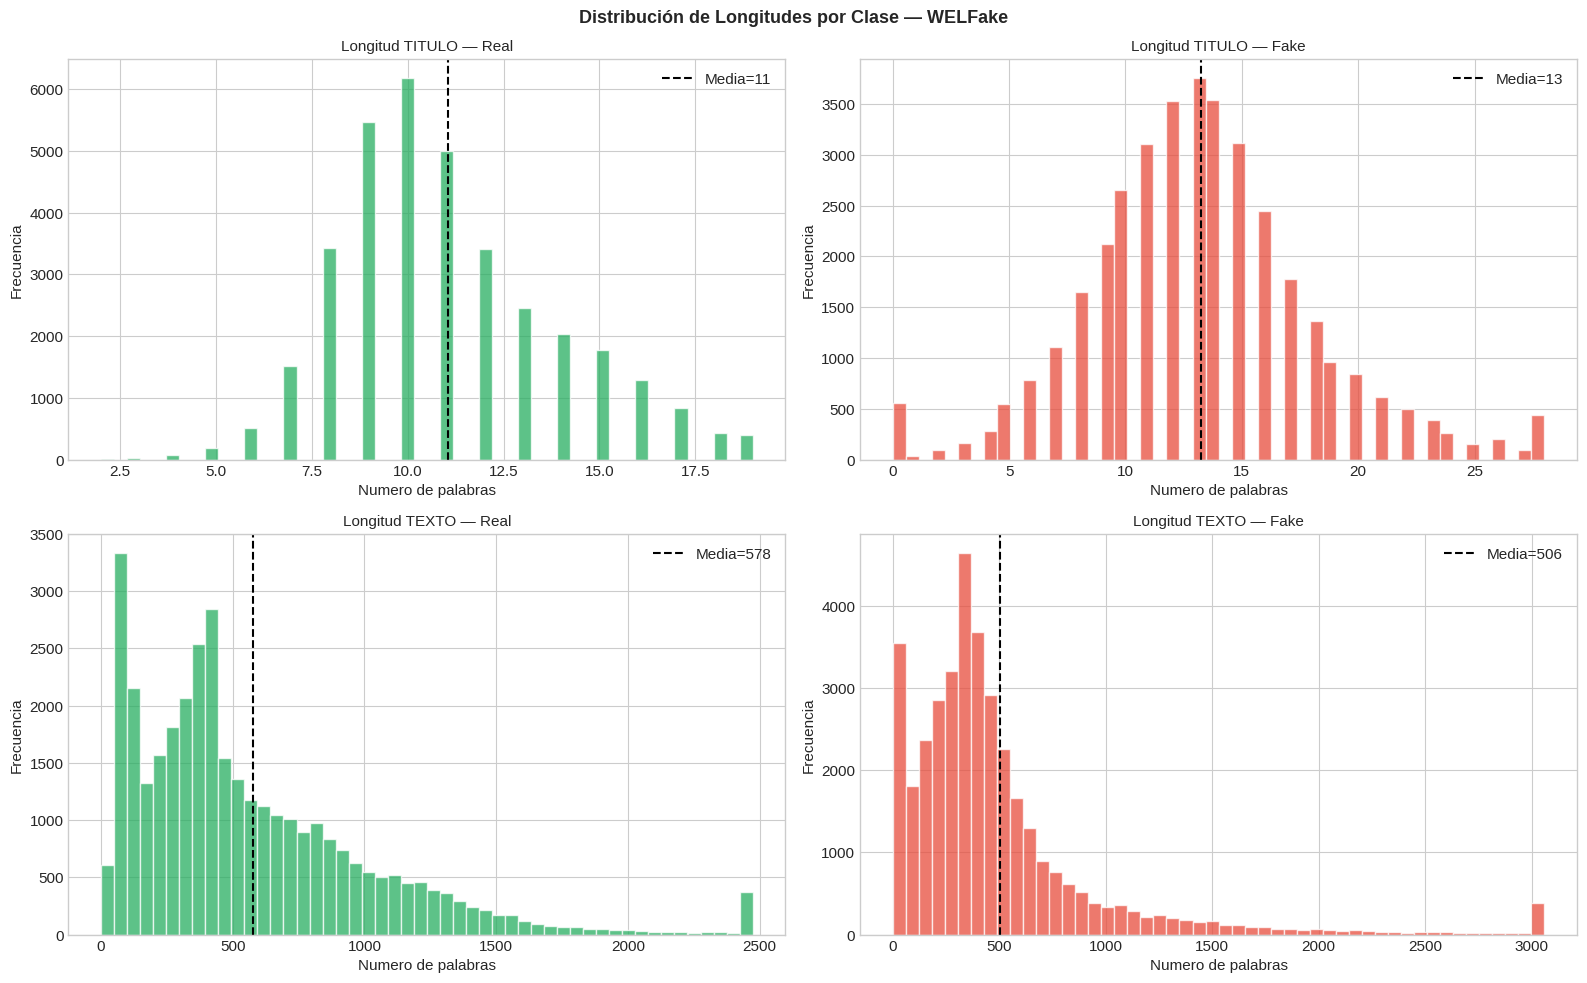

In [ ]:
df_w['text']  = df_w['text'].fillna('')
df_w['title'] = df_w['title'].fillna('')
df_w['title_len'] = df_w['title'].apply(lambda x: len(str(x).split()))
df_w['text_len']  = df_w['text'].apply(lambda x: len(str(x).split()))

for col, field in [('title_len', 'TÍTULO'), ('text_len', 'TEXTO')]:
    print(f'--- {field} ---')
    print(f'  Media: {df_w[col].mean():.1f}  |  Mediana: {df_w[col].median():.1f}  |  Max: {df_w[col].max()}')
    for label, lname in {0:'Real', 1:'Fake'}.items():
        s = df_w[df_w['label']==label][col]
        print(f'    {lname}: media={s.mean():.1f}, mediana={s.median():.1f}')

**Observación:** 
- Los títulos son cortos (~12 palabras). Las noticias **fake** tienden a tener títulos un poco más largos (13.2 vs 11.0), posiblemente más sensacionalistas.
- Los textos son extensos (mediana ~398 palabras). Las noticias **reales** son ligeramente más largas (427 vs 369 palabras de mediana).
- La distribución del texto está fuertemente sesgada a la derecha (hay artículos de más de 24,000 palabras).

### Reto 1.4 — Valores nulos

In [ ]:
print('Valores nulos por columna:')
print(df_w[['title','text','label']].isnull().sum())
print(f'\nTextos vacíos (cadena vacía): {(df_w["text"].str.strip() == "").sum():,}')
print(f'Títulos vacíos: {(df_w["title"].str.strip() == "").sum():,}')

Valores nulos por columna:
title    0
text     0
label    0
dtype: int64

Textos vacíos (cadena vacía): 783
Títulos vacíos: 558


In [ ]:
# Estrategia: eliminar filas con texto vacío
rows_before = len(df_w)
df_w = df_w[df_w['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Filas antes: {rows_before:,}  →  después: {len(df_w):,}  (eliminadas: {rows_before-len(df_w):,})')
print(f'Nulos restantes: {df_w.isnull().sum().sum()}')

Filas antes: 72,134  →  después: 71,351  (eliminadas: 783)
Nulos restantes: 0


**Decisión documentada:**
- Los valores NaN se rellenaron con `''` mediante `fillna()`.
- Se eliminaron las 783 filas con texto vacío (**1.08% del total**) — sin texto no hay información para clasificar.
- Los títulos vacíos se mantienen con `''` (el texto es la fuente primaria de información).
- **Justificación:** el porcentaje es mínimo y no afecta el balance de clases significativamente.

### Reto 1.5 — Duplicados

In [ ]:
n_dup = df_w.duplicated(subset=['text'], keep='first').sum()
print(f'Filas duplicadas: {n_dup:,} ({n_dup/len(df_w)*100:.2f}%)')

rows_before = len(df_w)
df_w = df_w.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f'Filas: {rows_before:,} → {len(df_w):,} (eliminadas: {rows_before-len(df_w):,})')

print('\nBalance tras deduplicar:')
for label, count in df_w['label'].value_counts().sort_index().items():
    print(f'  {class_names_w[label]}: {count:,} ({count/len(df_w)*100:.1f}%)')

Filas duplicadas: 8,636 (12.10%)
Filas: 71,351 → 62,715 (eliminadas: 8,636)

Balance tras deduplicar:
  Real: 34,620 (55.2%)
  Fake: 28,095 (44.8%)


**Observación crítica:**
- El **12.1% de duplicados** es sustancial y su eliminación cambió el balance de 48.6%/51.4% a **55.2%/44.8%**.
- Las noticias **fake** tenían más duplicados (posiblemente distribuidas masivamente por múltiples fuentes).
- **Sin eliminación**: si el mismo texto aparece en train y test, el modelo "memoriza" en lugar de generalizar → **data leakage** → métricas artificialmente infladas.

### Reto 1.6 — Nubes de palabras

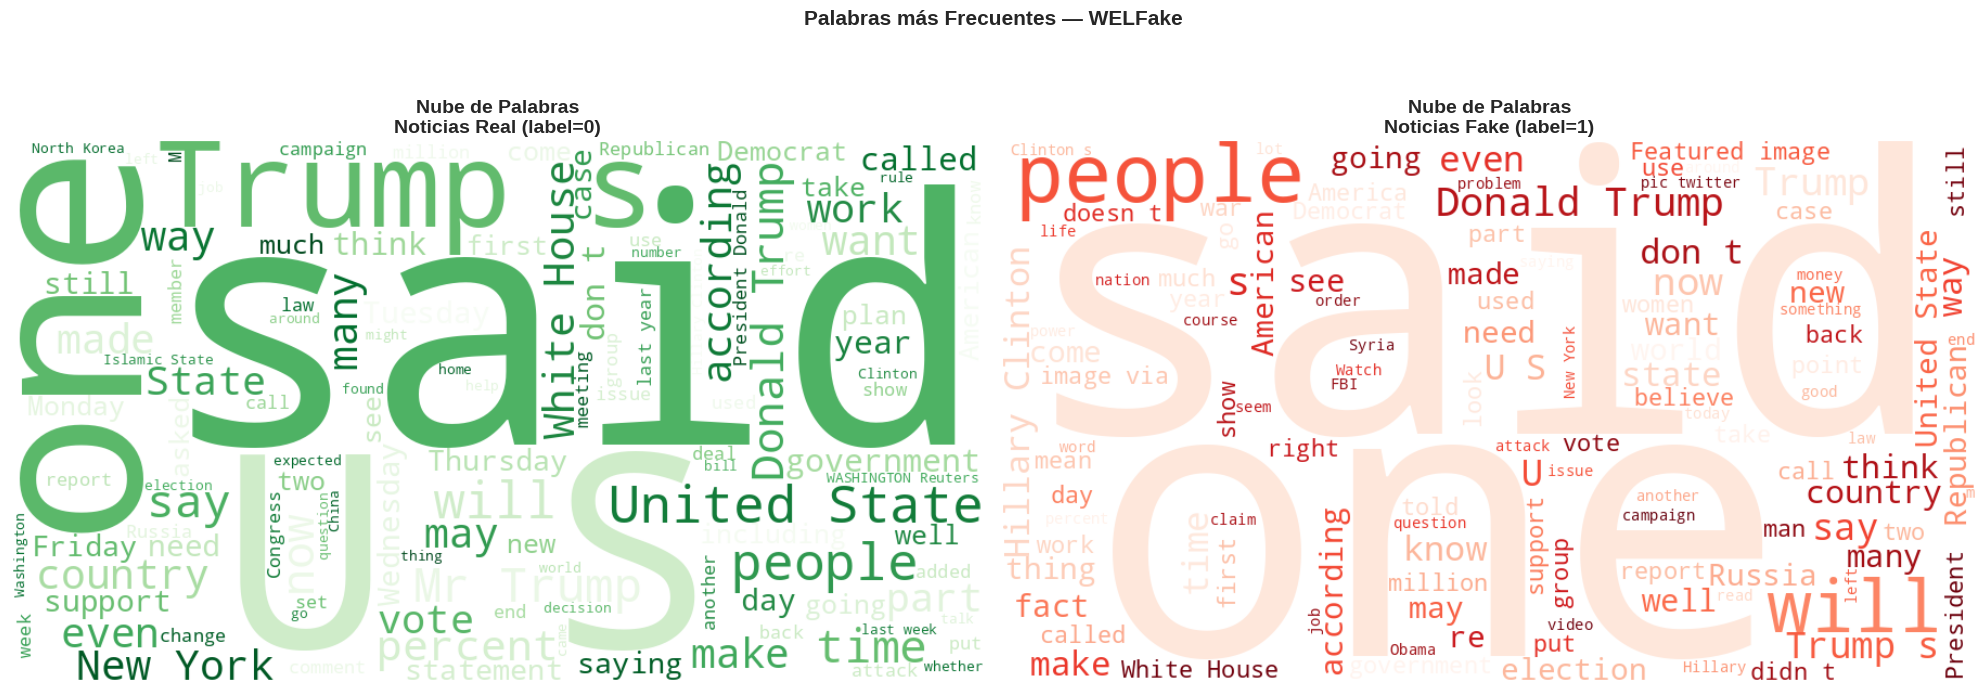

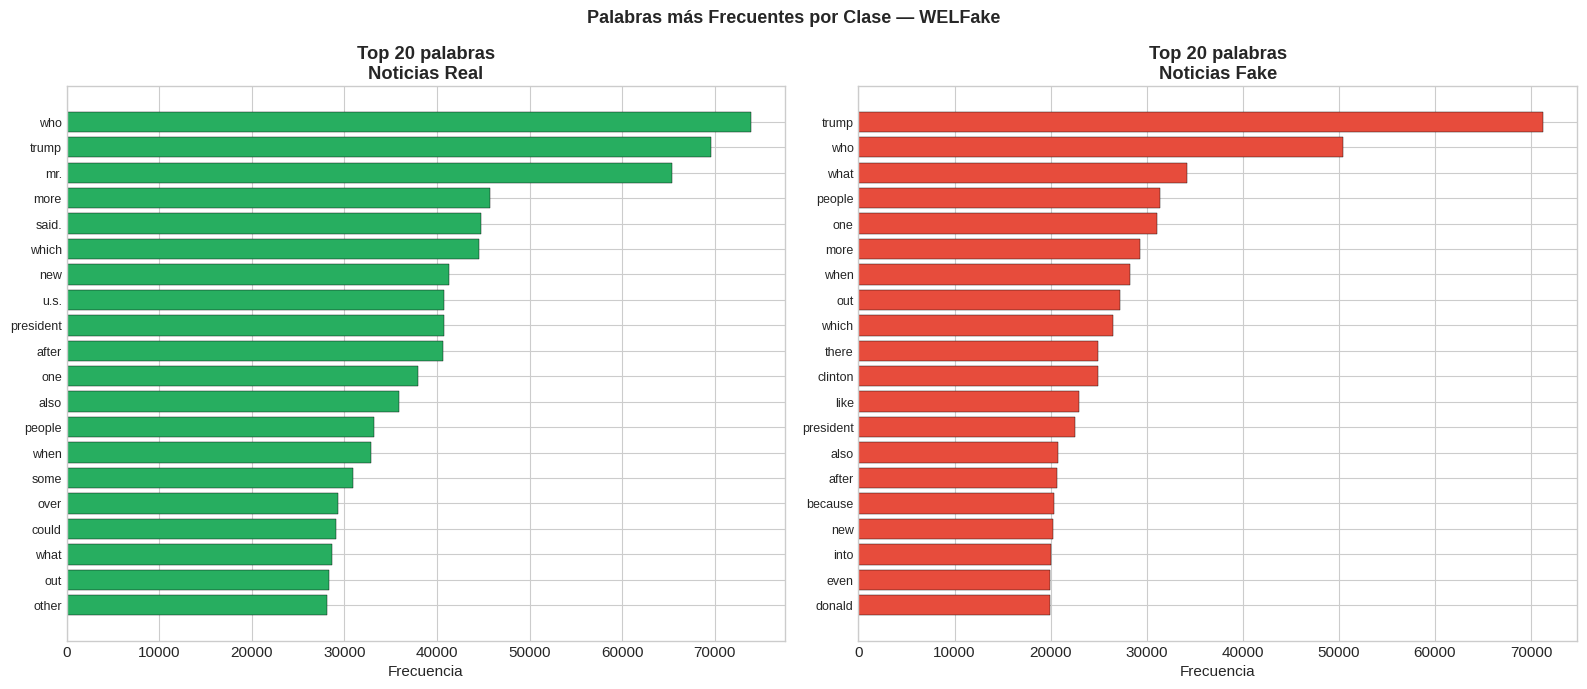

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for idx, (label, name, cmap) in enumerate([(0,'Real','Greens'),(1,'Fake','Reds')]):
    text = ' '.join(df_w[df_w['label']==label]['text'].astype(str).values)
    wc = WordCloud(width=900, height=500, max_words=120, background_color='white',
                   colormap=cmap, random_state=42).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras — Noticias {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

**Observaciones:**
- Ambas clases comparten palabras genéricas: "said", "Trump", "people", "president".
- Las noticias **Fake** muestran mayor presencia de términos sensacionalistas y personajes políticos.
- Las noticias **Reales** muestran vocabulario más formal y periodístico.
- Las nubes muestran frecuencia bruta — para importancia discriminativa necesitaremos **TF-IDF**.

### Reto 1.7 — ¿Qué porcentaje se truncaría con max_len=200?

In [ ]:
pct_over_200 = (df_w['text_len'] > 200).mean() * 100
print(f'Textos con MÁS de 200 palabras: {pct_over_200:.1f}%')
print(f'Textos con 200 palabras o menos: {100-pct_over_200:.1f}%')

print('\nPercentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  Percentil {p}: {np.percentile(df_w["text_len"], p):.0f} palabras')

Textos con MÁS de 200 palabras: 79.4%
Textos con 200 palabras o menos: 20.6%

Percentiles:
  Percentil 50: 406 palabras
  Percentil 75: 679 palabras
  Percentil 90: 1108 palabras
  Percentil 95: 1404 palabras
  Percentil 99: 2664 palabras


**Respuesta:** Con `max_len=200`, se truncaría el **79.4%** de los textos (la mediana es 406 palabras).

**Recomendación para max_len:**
| Valor | % completos | Trade-off |
|-------|------------|-----------|
| 200 | 20.6% | Muy rápido, mucha pérdida de información |
| 400 | ~50% | Compromiso razonable |
| 500 | ~60% | **Recomendado** — captura la mediana completa |
| 700 | ~75% | Preserva el Percentil 75, más costo GPU |

> Nota: BERT tiene límite de 512 tokens (sub-palabras, no palabras).

---
## Preguntas de Reflexión

### R1. ¿Por qué es importante el EDA?
El EDA es fundamental porque:
1. **Detecta problemas de calidad** antes de que contaminen el modelo (nulos, duplicados, textos vacíos)
2. **Revela distribuciones** que informan decisiones de diseño (ej: elegir max_len=500 en lugar de 200)
3. **Valida supuestos** sobre los datos (¿están balanceadas las clases?)
4. **Genera hipótesis** sobre qué features serán útiles

Sin EDA, entrenaríamos un modelo con 12% de duplicados que inflaría artificialmente las métricas.

---

### R2. ¿Balanceado o desbalanceado? ¿Cómo mitiga el desbalance?
El dataset WELFake está **balanceado** (48.6%/51.4%, ratio 1.06:1). Tras eliminar duplicados cambia a 55.2%/44.8%.

Un desbalance severo (90%/10%) haría que el modelo prediga siempre la clase mayoritaria (accuracy=90% "gratis"). Para mitigarlo:
- **Oversampling**: SMOTE duplica sintéticamente ejemplos de la clase minoritaria
- **Undersampling**: reduce la clase mayoritaria
- **class_weight='balanced'**: penaliza más los errores en la clase minoritaria
- **Umbral de decisión**: ajustar el threshold de probabilidad

---

### R3. ¿Las noticias falsas son más largas o más cortas?
Las noticias **reales** son ligeramente más largas (mediana=427 palabras vs 369 de las fake). Posibles razones:
- El periodismo formal incluye más contexto, fuentes citadas y desarrollo narrativo.
- Las fake news priorizan impacto emocional sobre profundidad argumental.
- Las noticias reales de Reuters/AP tienen formato estandarizado con mayor extensión.

Los títulos **fake** son más largos (13.2 vs 11.0 palabras), sugiriendo mayor sensacionalismo.

---

### R4. ¿Cómo elegir max_len? Trade-off información vs. costo computacional
Con max_len=200 se perdería información del **79.4%** de los textos.

- Mayor max_len → más información preservada → mejor accuracy potencial → más memoria GPU y tiempo de entrenamiento (cuadrático en Transformers)
- **Elección razonable**: max_len=500 captura el 60% completo de los textos con costo moderado.
- Estrategia: primero entrenar con max_len pequeño para prototipar rápido, luego aumentar para el modelo final.

---

### R5. Estrategia para valores nulos — ¿cuándo eliminar vs. rellenar?
Se eligió **eliminar** filas con texto vacío (783 filas, 1.08%) porque sin texto no hay información para clasificar.

**¿Cuándo rellenar?**
- Si los nulos tienen significado propio (ej: "artículo sin cuerpo = posiblemente clickbait")
- Si el porcentaje es alto y eliminar generaría sesgo
- Con un marcador especial `[EMPTY]` que el modelo aprenda a reconocer

**¿Cuándo eliminar?**
- Cuando el porcentaje es pequeño (<2%) y no introduce sesgo
- Cuando la fila es completamente inútil para el objetivo

---

### R6. ¿Por qué son críticos los duplicados (data leakage)?
El **12.1% de duplicados** en WELFake es sustancial. Si no se eliminan:
1. El mismo texto puede aparecer en **train y test** → el modelo "memoriza" en lugar de generalizar
2. Las métricas (accuracy, F1) se inflan artificialmente → el modelo parece mejor de lo que es
3. El modelo no aprenderá a generalizar a noticias nunca vistas

Además, los duplicados sesgaron el balance de clases: las fake tenían más copias, sugiriendo que se viralizan más.

---

### R7. Limitaciones del EDA
No exploramos:
1. **Estructura superficial del texto**: signos de exclamación (!), mayúsculas (CAPS LOCK), emojis — típicos del sensacionalismo
2. **Análisis de sentimiento**: las fake news suelen tener tono más emocional/negativo
3. **Metadatos de fuente**: la URL o el nombre del medio podría ser un predictor poderoso
4. **Vocabulario temporal**: palabras clave cambian con el tiempo (una noticia de 2016 vs 2024)
5. **Distribución n-gramas**: frases de 2-3 palabras pueden ser más discriminativas que palabras sueltas

---

### R8. Impacto social y ética
Detectar fake news es poderoso pero conlleva responsabilidades críticas:
- **Falsos Positivos**: censurar periodismo legítimo → afecta libertad de prensa y pluralismo informativo
- **Falsos Negativos**: dejar pasar desinformación → puede causar pánico, violencia, decisiones políticas erróneas

Como ingenieros debemos:
- Ser **transparentes** sobre las limitaciones del modelo
- **No usar el clasificador como árbitro absoluto** — debe ser una herramienta de apoyo, no de censura automatizada
- Considerar **quién define la verdad** en contextos político y culturales distintos
- Auditar el modelo por **sesgos** (¿clasifica peor para ciertos medios o ideologías?)

---

### R9. ¿Título o texto? ¿Qué features serán más útiles?
Ambos son útiles de formas distintas:
- El **texto** contiene más información y contexto → mejor para modelos profundos (LSTM, BERT)
- El **título** es más corto pero más directo → puede capturar sensacionalismo eficientemente
  - Títulos fake son más largos en promedio (13.2 vs 11.0 palabras) → señal discriminativa
  - Los modelos rápidos (TF-IDF + Logistic Regression) pueden funcionar bien solo con títulos

**Recomendación:** combinar título + texto (concatenados o como features separados) para el entrenamiento final.

**Features potencialmente útiles descubiertos en el EDA:**
- Longitud del texto (las reales son más largas)
- Longitud del título (las fake son más largas)
- Vocabulario específico de cada clase (identificado en nubes de palabras)
- Ratio de signos de exclamación / mayúsculas (no explorado pero prometedor)

---
## Resumen del Dataset Limpio

In [ ]:
print('=== DATASET WELFake — ESTADO FINAL ===')
print(f'Total filas: {len(df_w):,}')
print(f'Columnas: {list(df_w.columns)}')
print()
for label, count in df_w['label'].value_counts().sort_index().items():
    print(f'  {class_names_w[label]}: {count:,} ({count/len(df_w)*100:.1f}%)')
print()
print(f'  Nulos restantes: {df_w.isnull().sum().sum()}')
print(f'  Duplicados: {df_w.duplicated(subset=["text"]).sum()}')
print(f'  Longitud media del texto: {df_w["text_len"].mean():.0f} palabras')
print()
print('Listo para el Notebook 02 — Baselines!')

=== DATASET WELFake — ESTADO FINAL ===
Total filas: 62,715
Columnas: ['title', 'text', 'label', 'title_len', 'text_len']

  Real: 34,620 (55.2%)
  Fake: 28,095 (44.8%)

  Nulos restantes: 0
  Duplicados: 0
  Longitud media del texto: 567 palabras

Listo para el Notebook 02 — Baselines!
